In [21]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch import Tensor
import matplotlib.pyplot as plt

### 데이터 불러오기

In [22]:
loaded_data = np.loadtxt('../data/pima_indians_diabetes/diabetes_train.csv', delimiter=',', skiprows=1)

x_train_np = loaded_data[:, 1:-1]
y_train_np = loaded_data[:, [-1]]

In [23]:
print('loaded_data.shape = ', loaded_data.shape)
print('x_train_np.shape = ', x_train_np.shape)
print('y_train_np.shape = ', y_train_np.shape)

loaded_data.shape =  (576, 10)
x_train_np.shape =  (576, 8)
y_train_np.shape =  (576, 1)


### 데이터셋 선언

In [24]:
x_train = torch.Tensor(x_train_np)
y_train = torch.Tensor(y_train_np)

class CustomDataset(Dataset):
    
    def __init__(self, x_train, y_train) -> None:
        self.x_train:Tensor = x_train
        self.y_train:Tensor = y_train
        
    def __getitem__(self, index):
        return self.x_train[index], self.y_train[index]
    
    def __len__(self):
        return self.x_train.shape[0]

dataset = CustomDataset(x_train, y_train)

In [25]:
train_loader = DataLoader(dataset=dataset, batch_size=64, shuffle=True)

### 모델 선언

In [26]:
class MyLogisticRegressionModel(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        
        self.logistic_stack = nn.Sequential(
            nn.Linear(8, 8),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
        
    def forward(self, data):
        pred = self.logistic_stack(data)
        
        return pred

In [27]:
model = MyLogisticRegressionModel()

for param in model.parameters():
    print(param)

Parameter containing:
tensor([[ 0.2036,  0.0020, -0.2291,  0.3063,  0.3391, -0.1592,  0.0860, -0.2978],
        [-0.1274, -0.0175, -0.1039, -0.1821, -0.2629, -0.0480, -0.2686,  0.2109],
        [ 0.3025,  0.2200,  0.0921,  0.3122, -0.2281, -0.0304, -0.2337, -0.2281],
        [ 0.0970, -0.2363, -0.0392,  0.2587,  0.0590, -0.0233,  0.1483, -0.1744],
        [ 0.0301, -0.1527, -0.1450, -0.3429, -0.1629,  0.2005,  0.3506,  0.1875],
        [ 0.3125, -0.1629,  0.0043,  0.2477, -0.1104,  0.1731, -0.1934, -0.3161],
        [-0.0921, -0.2914,  0.1724, -0.1912, -0.0486,  0.2018,  0.1407, -0.1370],
        [-0.1632,  0.0619,  0.2463,  0.1501,  0.2416, -0.2609, -0.3345,  0.0038]],
       requires_grad=True)
Parameter containing:
tensor([-0.2720, -0.0756,  0.0352,  0.0373,  0.1560, -0.0253, -0.1227, -0.3280],
       requires_grad=True)
Parameter containing:
tensor([[ 0.2740, -0.0463, -0.2942, -0.1412,  0.3405,  0.3506,  0.2258, -0.2742]],
       requires_grad=True)
Parameter containing:
tensor([0.

### 손실함수, 옵티마이저 선언

In [28]:
loss_function = nn.BCELoss()
optim = torch.optim.SGD(model.parameters(), lr=1e-4)

### 학습

In [29]:
train_loss_list = []
train_accuracy_list = []

NUM_EPOCH = 5000

for epoch in range(NUM_EPOCH + 1):
    
    epoch_loss = 0
    batch_correct = []
    
    for idx, batch_data in enumerate(train_loader):
        x_train_batch, y_train_batch = batch_data
        
        outputs = model(x_train_batch)
        
        loss = loss_function(outputs, y_train_batch)
        epoch_loss += loss.item()
        
        prediction = outputs > 0.5
        correct = (prediction.float() == y_train_batch)
        batch_correct.extend(correct.numpy().flatten())
        
        optim.zero_grad()
        loss.backward()
        optim.step()
        
    train_loss_list.append(epoch_loss)
    accuracy = np.array(batch_correct).sum() / len(batch_correct)
    train_accuracy_list.append(accuracy)
    
    if epoch % 100 == 0:
        print(f"epoch = {epoch}, current loss = {epoch_loss} accuracy = {accuracy}")

epoch = 0, current loss = 123.56716823577881 accuracy = 0.6614583333333334
epoch = 100, current loss = 6.802269220352173 accuracy = 0.6163194444444444
epoch = 200, current loss = 6.181913375854492 accuracy = 0.6371527777777778
epoch = 300, current loss = 5.821203291416168 accuracy = 0.6631944444444444
epoch = 400, current loss = 5.671830654144287 accuracy = 0.6822916666666666
epoch = 500, current loss = 5.567720949649811 accuracy = 0.6857638888888888
epoch = 600, current loss = 5.506892621517181 accuracy = 0.6927083333333334
epoch = 700, current loss = 5.508776426315308 accuracy = 0.6961805555555556
epoch = 800, current loss = 5.480509698390961 accuracy = 0.6875
epoch = 900, current loss = 5.478179037570953 accuracy = 0.6840277777777778
epoch = 1000, current loss = 5.500169634819031 accuracy = 0.6979166666666666
epoch = 1100, current loss = 5.4838263392448425 accuracy = 0.6961805555555556
epoch = 1200, current loss = 5.467702507972717 accuracy = 0.6892361111111112
epoch = 1300, current

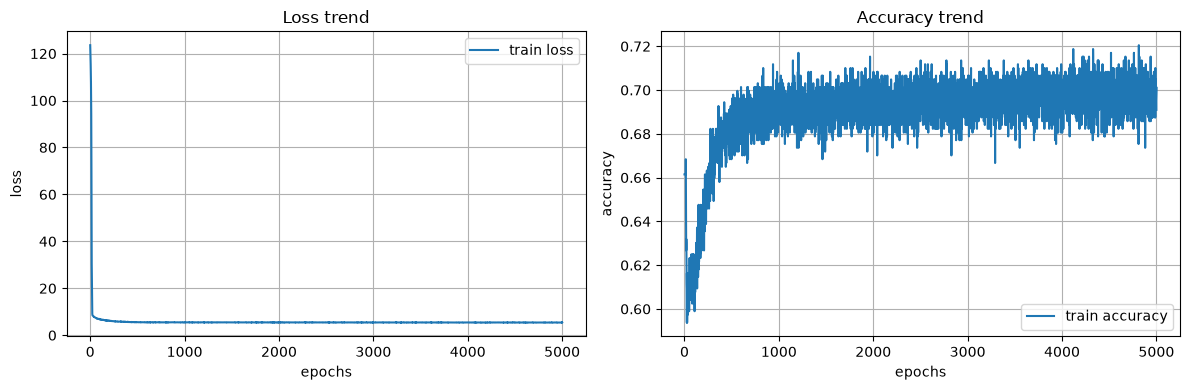

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.set_title('Loss trend')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.grid()
ax1.plot(train_loss_list, label='train loss')
ax1.legend(loc='best')

ax2.set_title('Accuracy trend')
ax2.set_xlabel('epochs')
ax2.set_ylabel('accuracy')
ax2.grid()
ax2.plot(train_accuracy_list, label='train accuracy')
ax2.legend(loc='best')

plt.tight_layout()
plt.show()